# Search for Co-transmitting Neurons

In [1]:
# Add auto reload
%load_ext autoreload
%autoreload 2

## Initial set up 
I will use both the codex and fafbseg libraries to obtain data. These tokens should be in the `.env` file. The actual tokens are stored in the OnePassword vault.

In [2]:
#libraries
import os
import numpy as np
import pandas as pd
from decouple import config, Config, RepositoryEnv
from caveclient import CAVEclient
from fafbseg import flywire
from getpass import getpass
import seaborn as sns
import matplotlib.pyplot as plt
import navis
import datetime

# Get variables from the .env file
ENV_PATH = "../.env"
config = Config(RepositoryEnv(ENV_PATH))

### CAV Client ###
# Get the CAVE_AUTH_TOKEN
cave_token = config("CAVE_AUTH_TOKEN", default=None)
if not cave_token:
    print("No CAVE token found in the .env file.")
    temp_token = getpass("Token not found in the .env file. Please enter your CAVE token (if you don't have one leave if blank and instructions will appear): ")
    if temp_token:
        cave_token = temp_token
    else:
        print("No CAVE token entered. Follow the information below to get a token.")
        CAVEclient.auth.get_new_token()
if cave_token:
    # Initialize the CAVE client
    client = CAVEclient('flywire_fafb_public')
    auth = client.auth
    tk = auth.token
    if not tk:
        print("Adding the token to your account. You only need to do this once.")
        auth.save_token(cave_token)
    else:
        print("CAVE token already exists in your account. No need to add it again.")

### Get the FLYWIRE_AUTH_TOKEN ###
flywire_token = config("FLYWIRE_AUTH_TOKEN", default=None)
tk = flywire.get_chunkedgraph_secret()
if not tk:
    print("No FLYWIRE token saved. Setting it with the value from the .env file.")
    if not flywire_token:
        flywire_token = getpass("Token not found in the .env file. Please enter your FLYWIRE token (if you don't have one leave if blank and instructions will appear): ")
        if not flywire_token:
            print("No FLYWIRE token entered. Follow the information below to get a token.")
            flywire.get_new_token()
        else:
            print("Setting the FLYWIRE token with the value from the .env file.")
            #Save the secret
            flywire.set_chunkedgraph_secret(flywire_token)
else:
    print("FLYWIRE token already exists in your account. No need to add it again.")

/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CAVE token already exists in your account. No need to add it again.
FLYWIRE token already exists in your account. No need to add it again.


## Test that the CAVE client works

In [3]:
root_id= "720575940624928574"
pre_df = client.materialize.query_table(
    table='synapses_nt_v1',
    filter_in_dict={'pre_pt_root_id': [root_id]},
)

In [4]:
pre_df

,id,created,superceded_id,valid,connection_score,cleft_score,gaba,ach,glut,oct,ser,da,valid_nt,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position
0,214660960,2021-03-09 20:14:58.183080+00:00,NaN,t,178.443710,146,0.573427,0.012797,0.357354,3.171137e-02,1.120479e-02,1.350511e-02,t,82192342869822207,720575940624928574,82192342869815634,720575940619434712,"[672464, 123968, 128240]","[672424, 123856, 128200]"
1,212755160,2021-03-09 20:14:58.183080+00:00,NaN,t,63.837860,0,0.002260,0.000186,0.004339,1.661167e-02,3.335109e-02,9.432522e-01,t,83037592433525500,720575940624928574,83037592433526880,720575940631766339,"[722744, 172224, 124160]","[722836, 172388, 124160]"
2,180092872,2021-03-09 20:14:58.183080+00:00,NaN,t,608.718506,145,0.792426,0.081848,0.116859,1.539643e-03,1.356865e-03,5.971514e-03,t,82544186523740614,720575940624928574,82544186523741768,720575940637335262,"[693408, 125320, 113120]","[693384, 125416, 113120]"
3,117358129,2021-03-09 20:14:58.183080+00:00,NaN,t,541.228027,142,0.912269,0.000142,0.087586,5.496258e-07,4.089258e-07,8.404323e-07,t,82896305189929007,720575940624928574,82896305189918198,720575940627196691,"[716104, 138956, 142000]","[716116, 139084, 142000]"
4,117340484,2021-03-09 20:14:58.183080+00:00,NaN,t,314.917725,46,0.035379,0.177907,0.616214,7.871953e-04,5.352731e-02,1.161863e-01,t,82825867726245398,720575940624928574,82825867726241325,720575940622726271,"[709816, 136728, 142040]","[709752, 136656, 142080]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2766,10743551,2021-03-09 20:14:58.183080+00:00,NaN,t,655.441223,150,0.941407,0.005157,0.051837,2.727648e-05,6.850158e-04,8.867508e-04,t,82474092590510391,720575940624928574,82474092590497553,720575940623922615,"[690212, 139336, 96520]","[690344, 139308, 96480]"
2767,40985835,2021-03-09 20:14:58.183080+00:00,NaN,t,93.763893,0,0.002389,0.006210,0.027201,6.384544e-01,1.675431e-01,1.582020e-01,t,82334042430942262,720575940624928574,82334042430935605,720575940625926693,"[680560, 179820, 130640]","[680452, 179976, 130680]"
2768,147201533,2021-03-09 20:14:58.183080+00:00,NaN,t,181.298172,158,0.186410,0.013800,0.085931,3.683391e-03,2.395421e-02,6.862214e-01,t,82755773792818138,720575940624928574,82755773792822932,720575940630964311,"[707976, 150860, 118800]","[707856, 150800, 118800]"
2769,163651016,2021-03-09 20:14:58.183080+00:00,NaN,t,405.936523,145,0.745807,0.033300,0.219379,7.945794e-04,1.878755e-04,5.321079e-04,t,82544461334748623,720575940624928574,82544461334739577,720575940624694601,"[693412, 141412, 98160]","[693408, 141508, 98160]"


## Build a function to identify highly contributing neurons
Idea: Test ratios of synapses in order to confirm contributions

In [12]:
# Function 1: Get the dataframes
def get_codex_synapse_predictions(root_id, client):
    """
    Function to gather synapse predictions for a given root ID.
    """

    # Pull initial data from the CAVE client
    pre_df = client.materialize.query_table(
        table='synapses_nt_v1',
        filter_in_dict={'pre_pt_root_id': [root_id]},
    )

    return pre_df

# Function 2: Get the neuron skeleton
def get_neuron_skeleton(root_id):
    """
    Function to gather the neuron skeleton for a given root ID.
    """
    neuron_skeleton = flywire.get_skeletons(root_id)

    return neuron_skeleton

# Function 3: Identify NT contributions per neuron
def identify_nt_contributions(pre_df, softmax_threshold=0.25):
    """
    Function to identify neurotransmitter contributions per neuron.
    Inputs:
    pre_df: DataFrame containing synapse predictions with columns for each neurotransmitter type.
    softmax_threshold: Float, the threshold below which a neurotransmitter is considered 'Unknown'.

    Returns:
    nt_counts: a dictionary with counts of each neurotransmitter type.
    synapse_predictions: a numpy array with synapse predictions for each neurotransmitter type. (NB excludes 'Unknown' type)
    """

    #Synapse predictions
    synapse_predictions = np.zeros((len(pre_df), 6), dtype=np.float32)
    for i in range(pre_df.shape[0]):
        row = [pre_df.iloc[i]['gaba'], pre_df.iloc[i]['ach'], pre_df.iloc[i]['glut'], pre_df.iloc[i]['oct'], pre_df.iloc[i]['ser'], pre_df.iloc[i]['da']]
        synapse_predictions[i] = row
        
    # Define neurotransmitter types
    nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
    
    # Initialize counts and filter along softmax values
    nt_counts = {nt: 0 for nt in nt_types}
    softmax_prediction_vals = {nt: [] for nt in nt_types}

    for i in range(pre_df.shape[0]):
        # Determine the synapse type based on the maximum prediction value  
        synapse_type = np.argmax(pre_df.iloc[i][['gaba', 'ach', 'glut', 'oct', 'ser', 'da']].values)
        softmax_val = np.max(pre_df.iloc[i][['gaba', 'ach', 'glut', 'oct', 'ser', 'da']].values)
        if softmax_val < softmax_threshold:
            synapse_type = 6  # Assign 'Unknown' if below threshold
        
        # Add the softmax value to the corresponding neurotransmitter type
        softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
        
        # Increment the count for the neurotransmitter type
        nt_counts[nt_types[synapse_type]] += 1
    
    # Convert to ratios
    total_synapses = pre_df.shape[0]
    for nt in nt_counts.keys():
        if total_synapses > 0:
            nt_counts[nt] = nt_counts[nt] / total_synapses
        else:
            nt_counts[nt] = 0
    
    return nt_counts, synapse_predictions

# Function 4: Predict which NTs the neuron uses via ratios
def predict_neurotransmitter_usage(nt_counts, ratio_threshold):
    """
    Function to predict which neurotransmitters a neuron uses based on ratios.
    Returns a list of neurotransmitter types that exceed the ratio threshold.

    Inputs:
    nt_counts: Dictionary with ratio of each neurotransmitter type.
    ratio_threshold: Float, the threshold above which a neurotransmitter is considered used.
    """
    ratio_predicted_nts = []
    
    for nt, ratio in nt_counts.items():
        if ratio >= ratio_threshold:
            ratio_predicted_nts.append(nt)
    
    return ratio_predicted_nts

### Now build a temporary function to test it

In [ ]:
def identify_nt_contributions_for_neuron(root_id, client, softmax_threshold=0.25, ratio_threshold=0.16, display_fig=False)-> list:
    """
    Function to identify neurotransmitter contributions per neuron.
    Returns a list of neurotransmitter types that exceed the ratio threshold.
    """
    # Get the synapse predictions
    pre_df = get_codex_synapse_predictions(root_id, client)
    
    # Identify neurotransmitter contributions
    nt_counts, synapse_predictions = identify_nt_contributions(pre_df, softmax_threshold)
    
    # Predict neurotransmitter usage based on ratios
    ratio_predicted_nts = predict_neurotransmitter_usage(nt_counts, ratio_threshold)

    # Print the results
    print(f"Neurotransmitter contributions for root ID {root_id}:")
    for nt, count in nt_counts.items():
        print(f"{nt}: {count:.2f}")
    
    print("\nPredicted neurotransmitters based on ratios:")
    for nt in ratio_predicted_nts:
        print(nt)

    if display_fig:
        neuron_skeleton = get_neuron_skeleton(root_id)
        # Plot the neuron skeleton with neurotransmitter contributions
        fig, ax = plt.subplots(2,4, figsize=(20, 10))

        # Plot the synapse predictions as a heatmap
        sns.heatmap(synapse_predictions, ax=ax[0,0])
        ax[0,0].set_title('Synapse Predictions Heatmap')
        ax[0,0].set_xlabel('Neurotransmitter Type')
        ax[0,0].set_xticks(np.arange(6) + 0.5)
        ax[0,0].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

        # Plot each row of the synapse predictions as a line plot
        for i in range(synapse_predictions.shape[0]):
            ax[0,1].plot(synapse_predictions[i], color='k', label=f'Synapse {i+1}', alpha=0.1)
        mean_predictions = np.mean(synapse_predictions, axis=0)
        median_predictions = np.median(synapse_predictions, axis=0)
        ax[0,1].plot(mean_predictions, label='Mean', color='r')
        ax[0,1].plot(median_predictions, label='Median', color='blue')
        ax[0,1].set_xlabel('Neurotransmitter Type')
        ax[0,1].set_xticks([0, 1, 2, 3, 4, 5])
        ax[0,1].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

        # Plot the neuron skeleton with the synapse predictions - all 3 combinations
        navis.plot2d(neuron_skeleton, ax=ax[1,0], color='k', view='xy')
        navis.plot2d(neuron_skeleton, ax=ax[1,1], color='k', view='yz')
        navis.plot2d(neuron_skeleton, ax=ax[1,2], color='k', view='xz')

        # Define neurotransmitter types and colors
        present_types = set()
        softmax_prediction_vals = {
            'GABA': [],
            'ACh': [],
            'Glut': [],
            'Oct': [],
            'Ser': [],
            'DA': [],
            'Unknown': []
        }
        nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
        colours = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow', 'gray']

        for i in range(synapse_predictions.shape[0]):
            # Determine the synapse type based on the maximum prediction value  
            synapse_type = np.argmax(synapse_predictions[i])
            softmax_val = np.max(synapse_predictions[i])
            if softmax_val < softmax_threshold:
                synapse_type = 6  # Assign 'Unknown' if below threshold
            colour = colours[synapse_type]
            present_types.add(synapse_type)

            # Add the softmax value to the corresponding neurotransmitter type
            softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
        
            # Find the position of the pre-synapse
            pos = pre_df.iloc[i]['pre_pt_position']
            pos_xy = (pos[0], pos[1])
            pos_yz = (pos[1], pos[2])
            pos_xz = (pos[0], pos[2])
        
            # Plot the synapse prediction on the neuron skeleton
            ax[1,0].plot(pos_xy[0], pos_xy[1], 'o', color=colour, markersize=2, alpha=0.75)
            ax[1,1].plot(pos_yz[0], pos_yz[1], 'o', color=colour, markersize=2, alpha=0.75)
            ax[1,2].plot(pos_xz[0], pos_xz[1], 'o', color=colour, markersize=2, alpha=0.75)
    
            # Create legend entries only for neurotransmitter types that are present
            legend_elements = []
            for nt_idx in sorted(present_types):
                legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                                markerfacecolor=colours[nt_idx], markersize=8,
                                                label=nt_types[nt_idx]))
        
            # Place the legend horizontally below the x-axis
            print(f"Debug: Legend elements: {legend_elements}")
            ax[1,0].legend(
                handles=legend_elements,
                loc='upper center',
                bbox_to_anchor=(0.5, -0.18),
                borderaxespad=0.,
                ncol=round(len(legend_elements)/2),
                frameon=False
            )
            ax[1,0].set_title('Neuron Skeleton with Synapse Predictions - Coronal')
            ax[1,1].set_title('Neuron Skeleton with Synapse Predictions - Sagittal')
            ax[1,2].set_title('Neuron Skeleton with Synapse Predictions - Axial')

            # Plot the counts of each neurotransmitter type
            ax[0,3].bar(nt_counts.keys(), nt_counts.values(), color=colours)
            ax[0,3].set_xlabel('Neurotransmitter Type')
            ax[0,3].set_ylabel('Count')
            ax[0,3].set_title('Counts of Neurotransmitter Types')

            # Plot the counts of each neurotransmitter type
            pcts = [nt_counts[nt] / synapse_predictions.shape[0] for nt in nt_counts.keys()]
            ax[1,3].bar(nt_counts.keys(), pcts, color=colours)
            ax[1,3].set_xlabel('Neurotransmitter Type')
            ax[1,3].set_ylabel('Ratios')
            ax[1,3].set_title('Ratios of Neurotransmitter Types')
            
            # Softmax confidence of the predictions
            sns.stripplot(data=softmax_prediction_vals, ax=ax[0,2])
            ax[0,2].set_title('Softmax Confidence of Predictions')
            ax[0,2].set_xlabel('Neurotransmitter Type')
            ax[0,2].set_ylabel('Softmax Confidence of chosen neurotransmitter')

            plt.suptitle(f'Synapse Predictions for Neuron {root_id} with Softmax Threshold {softmax_threshold}', fontsize=16)
            plt.tight_layout()
            plt.show()
    
    return ratio_predicted_nts

    

Neurotransmitter contributions for root ID 720575940624928574:
GABA: 0.55
ACh: 0.06
Glut: 0.34
Oct: 0.01
Ser: 0.01
DA: 0.03
Unknown: 0.00

Predicted neurotransmitters based on ratios:
GABA
Glut


ValueError: number sections must be larger than 0.

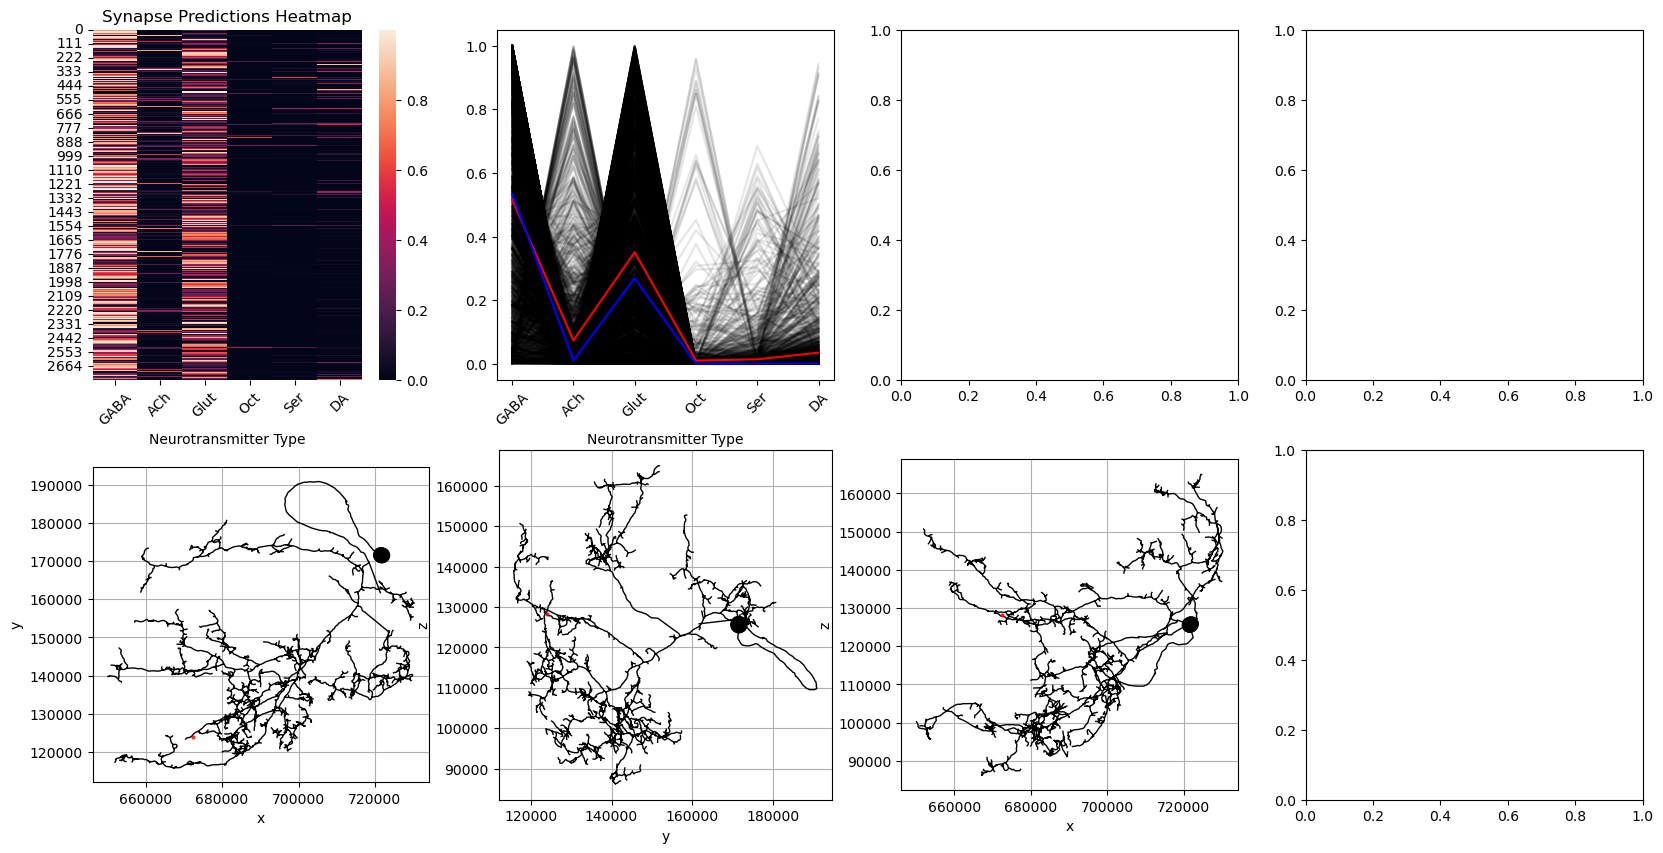

In [29]:
ratios = identify_nt_contributions_for_neuron(root_id, client, softmax_threshold=0.25, ratio_threshold=0.16, display_fig=True)

In [ ]:
def get_synapse_predictions(root_id, client, softmax_threshold=0.25):
    """
    Function to gather synapse predictions for a given root ID.
    Returns a DataFrame containing the synapse predictions alongside a N*6 array of the synapse predictions.
    """
    # 
    pre_df = client.materialize.query_table(
        table='synapses_nt_v1',
        filter_in_dict={'pre_pt_root_id': [root_id]},
    )

    # Now create an array of the synapse predictions
    synapse_predictions = np.zeros((len(pre_df), 6), dtype=np.float32)
    for i in range(pre_df.shape[0]):
        row = [pre_df.iloc[i]['gaba'], pre_df.iloc[i]['ach'], pre_df.iloc[i]['glut'], pre_df.iloc[i]['oct'], pre_df.iloc[i]['ser'], pre_df.iloc[i]['da']]
        synapse_predictions[i] = row
    # print(f"synapse_predictions: {synapse_predictions}")

    # Get the skeleton for the neuron
    neuron_skeleton = flywire.get_skeletons(root_id)
    
    #Now plot everything
    fig, ax = plt.subplots(2,4, figsize=(20, 10))

    # Plot the synapse predictions as a heatmap
    sns.heatmap(synapse_predictions, ax=ax[0,0])
    ax[0,0].set_title('Synapse Predictions Heatmap')
    ax[0,0].set_xlabel('Neurotransmitter Type')
    ax[0,0].set_xticks(np.arange(6) + 0.5)
    ax[0,0].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

    # Plot each row of the synapse predictions as a line plot
    for i in range(synapse_predictions.shape[0]):
        ax[0,1].plot(synapse_predictions[i], color='k', label=f'Synapse {i+1}', alpha=0.1)

    mean_predictions = np.mean(synapse_predictions, axis=0)
    median_predictions = np.median(synapse_predictions, axis=0)
    ax[0,1].plot(mean_predictions, label='Mean', color='r')
    ax[0,1].plot(median_predictions, label='Median', color='blue')

    ax[0,1].set_xlabel('Neurotransmitter Type')
    ax[0,1].set_xticks([0, 1, 2, 3, 4, 5])
    ax[0,1].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

    # Plot the neuron skeleton with the synapse predictions - all 3 combinations
    navis.plot2d(neuron_skeleton, ax=ax[1,0], color='k', view='xy')
    navis.plot2d(neuron_skeleton, ax=ax[1,1], color='k', view='yz')
    navis.plot2d(neuron_skeleton, ax=ax[1,2], color='k', view='xz')
    
    # Define neurotransmitter types and colors
    nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
    colors = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow', 'gray']
    
    # Keep track of which neurotransmitter types are present for the legend
    present_types = set()

    nt_counts = {
        'GABA': 0,
        'ACh': 0,
        'Glut': 0,
        'Oct': 0,
        'Ser': 0,
        'DA': 0,
        'Unknown': 0
    }
    softmax_prediction_vals = {
        'GABA': [],
        'ACh': [],
        'Glut': [],
        'Oct': [],
        'Ser': [],
        'DA': [],
        'Unknown': []
    }
    for i in range(synapse_predictions.shape[0]):
        # Determine the synapse type based on the maximum prediction value  
        synapse_type = np.argmax(synapse_predictions[i])
        softmax_val = np.max(synapse_predictions[i])
        if softmax_val < softmax_threshold:
            synapse_type = 6  # Assign 'Unknown' if below threshold
        color = colors[synapse_type]
        present_types.add(synapse_type)

        # Add the softmax value to the corresponding neurotransmitter type
        softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
        
        # Increment the count for the neurotransmitter type
        nt_counts[nt_types[synapse_type]] += 1

        # Find the position of the pre-synapse
        pos = pre_df.iloc[i]['pre_pt_position']
        pos_xy = (pos[0], pos[1])
        pos_yz = (pos[1], pos[2])
        pos_xz = (pos[0], pos[2])
        
        # Plot the synapse prediction on the neuron skeleton
        ax[1,0].plot(pos_xy[0], pos_xy[1], 'o', color=color, markersize=2, alpha=0.1)
        ax[1,1].plot(pos_yz[0], pos_yz[1], 'o', color=color, markersize=2, alpha=0.1)
        ax[1,2].plot(pos_xz[0], pos_xz[1], 'o', color=color, markersize=2, alpha=0.1)
    
    # Create legend entries only for neurotransmitter types that are present
    legend_elements = []
    for nt_idx in sorted(present_types):
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=colors[nt_idx], markersize=8,
                                        label=nt_types[nt_idx]))
    
    # Place the legend horizontally below the x-axis
    ax[1,0].legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.18),
        borderaxespad=0.,
        ncol=round(len(legend_elements)/2),
        frameon=False
    )
    ax[1,0].set_title('Neuron Skeleton with Synapse Predictions - Coronal')
    ax[1,1].set_title('Neuron Skeleton with Synapse Predictions - Sagittal')
    ax[1,2].set_title('Neuron Skeleton with Synapse Predictions - Axial')

    # Plot the counts of each neurotransmitter type
    ax[0,3].bar(nt_counts.keys(), nt_counts.values(), color=colors)
    ax[0,3].set_xlabel('Neurotransmitter Type')
    ax[0,3].set_ylabel('Count')
    ax[0,3].set_title('Counts of Neurotransmitter Types')

    # Plot the counts of each neurotransmitter type
    pcts = [nt_counts[nt] / synapse_predictions.shape[0] for nt in nt_counts.keys()]
    ax[1,3].bar(nt_counts.keys(), pcts, color=colors)
    ax[1,3].set_xlabel('Neurotransmitter Type')
    ax[1,3].set_ylabel('Ratios')
    ax[1,3].set_title('Ratios of Neurotransmitter Types')
    
    # Softmax confidence of the predictions
    sns.stripplot(data=softmax_prediction_vals, ax=ax[0,2])
    ax[0,2].set_title('Softmax Confidence of Predictions')
    ax[0,2].set_xlabel('Neurotransmitter Type')
    ax[0,2].set_ylabel('Softmax Confidence of chosen neurotransmitter')

    plt.suptitle(f'Synapse Predictions for Neuron {root_id} with Softmax Threshold {softmax_threshold}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return pre_df, synapse_predictions